# Cell Segmentation – SAM Training Notebook

Uses **SAM ViT-B** (`facebook/sam-vit-base`) as a frozen image encoder with a
lightweight trainable semantic decoder — for both 2D and 3D segmentation.

| Model | Training input | Inference input | Trainable params |
|---|---|---|---|
| `SAMSeg2D` | `(B, 256, 64, 64)` pre-cached emb. | `(B, 1, H, W)` raw | ~460 K |
| `SAMSeg3D` | `(B, D, 256, 64, 64)` per-slice emb. | `(B, 1, D, H, W)` raw | ~460 K |

### Why pre-extract embeddings?
SAM requires **exactly 1024×1024** input — this is a hard check in the HuggingFace
implementation (`SamPatchEmbeddings`). Running the encoder at 1024×1024 on CPU
takes ~5 s/image → ~80 min/epoch → impractical for training.  
**Solution:** run the encoder *once* on all data (Step 3 below), save the
`(256, 64, 64)` feature maps to disk, then train only the tiny decoder.

In [ ]:
# ── 0. Imports ──────────────────────────────────────────────────────────────
import os, sys
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

OWLO_DIR  = r'C:\Users\marti\Desktop\Owlo-test'
UTILS_DIR = os.path.join(OWLO_DIR, 'utils')
if UTILS_DIR not in sys.path:
    sys.path.insert(0, UTILS_DIR)

from models import SAMSeg2D, SAMSeg3D
from train_functions import (
    load_tif_stack, process_mask, compute_class_weights, CombinedLoss, train,
    make_dataloaders_sam_embed, make_dataloaders_sam_embed_3d,
    predict_slice, predict_slice_3d,
    plot_val_samples_sam_embed,
)

print('PyTorch:', torch.__version__)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', DEVICE)
CMAP = mcolors.ListedColormap(['black', 'deepskyblue', 'tomato'])

In [ ]:
# ── 1. Configuration ─────────────────────────────────────────────────────────
DATA_DIR  = r'C:\Users\marti\Downloads\2025-11-19_Simu_twocells\2025-11-19_Simu_twocells'
CKPT_DIR  = os.path.join(OWLO_DIR, 'model_weights')
EMBED_DIR = os.path.join(OWLO_DIR, 'sam_embeddings')  # where embeddings are cached

ALL_K        = list(range(100))
NUM_CLASSES  = 3
VAL_FRAC     = 0.15
SLICE_STRIDE = 2

TARGET_SIZE  = (128, 128)   # final output resolution (H, W)
DEPTH        = 5            # depth of 3D patches

# Decoder-only training is fast → larger batches are fine
BATCH_SIZE_2D = 16
BATCH_SIZE_3D = 8
NUM_EPOCHS_2D = 20
NUM_EPOCHS_3D = 20

Image stack : (61, 256, 255)  dtype=float32
Mask (raw)  : (61, 256, 255)  unique=[  0  51 102 153 204 255]
Mask (proc) : unique=[0 1 2]


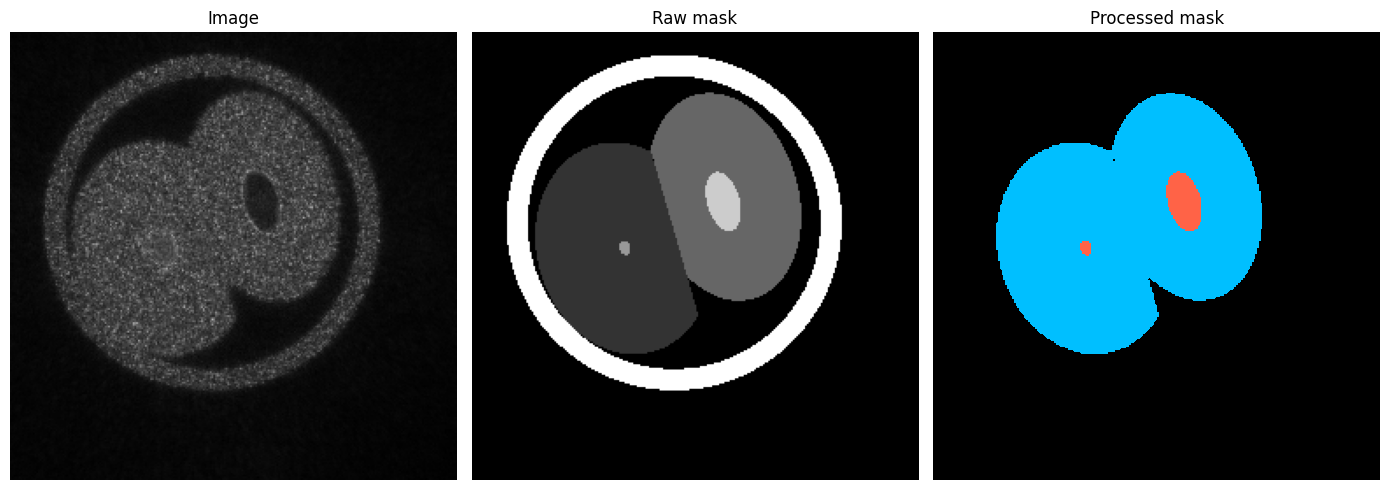

In [3]:
# ── 2. Data exploration ───────────────────────────────────────────────────────
k = 20
img_stack  = load_tif_stack(os.path.join(DATA_DIR, f'vol_linear_{k}.tif')).astype(np.float32) / 255.0
mask_stack = load_tif_stack(os.path.join(DATA_DIR, f'mask_{k}.tif'))
mask_proc  = np.stack([process_mask(m) for m in mask_stack])

print(f'Image stack : {img_stack.shape}  dtype={img_stack.dtype}')
print(f'Mask (raw)  : {mask_stack.shape}  unique={np.unique(mask_stack)}')
print(f'Mask (proc) : unique={np.unique(mask_proc)}')

s = 30
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img_stack[s],  cmap='gray', vmin=0, vmax=1); axes[0].set_title('Image')
axes[1].imshow(mask_stack[s], cmap='gray');                  axes[1].set_title('Raw mask')
axes[2].imshow(mask_proc[s],  cmap=CMAP, vmin=0, vmax=2);   axes[2].set_title('Processed mask')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

---
## Step 3 – Pre-extract SAM embeddings (run once)

This cell runs the SAM ViT-B encoder on every slice of every volume at 1024×1024
and saves `(256, 64, 64)` float16 embeddings to `sam_embeddings/emb_{k}.npz`.

**Expected time:** ~3 s/image × 61 slices × 100 volumes ≈ 5 h on CPU.  
**Storage:** ~60 MB/volume (compressed float16) × 100 ≈ 6 GB total.  
The cell skips volumes that are already cached — safe to interrupt and resume.

In [ ]:
# ── 3. Pre-extract SAM embeddings ────────────────────────────────────────────
from transformers import SamModel
from tqdm import tqdm

os.makedirs(EMBED_DIR, exist_ok=True)

# Load encoder once (facebook/sam-vit-base already downloaded)
_sam  = SamModel.from_pretrained('facebook/sam-vit-base')
_enc  = _sam.vision_encoder.eval()
_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
_std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

for k in ALL_K:
    save_path = os.path.join(EMBED_DIR, f'emb_{k}.npz')
    if os.path.exists(save_path):
        print(f'  k={k:3d}  already cached – skip')
        continue

    img_vol = load_tif_stack(os.path.join(DATA_DIR, f'vol_linear_{k}.tif')).astype(np.float32) / 255.0
    embs = []
    for s in tqdm(range(img_vol.shape[0]), desc=f'k={k:3d}', leave=False):
        img_t = torch.from_numpy(img_vol[s]).unsqueeze(0).unsqueeze(0)   # (1,1,H,W)
        img_t = F.interpolate(img_t, size=(1024, 1024), mode='bilinear', align_corners=False)
        img_t = img_t.expand(-1, 3, -1, -1).contiguous()
        img_t = (img_t - _mean) / _std
        with torch.no_grad():
            emb = _enc(pixel_values=img_t).last_hidden_state   # (1, 256, 64, 64)
        embs.append(emb.squeeze(0).half().numpy())              # float16

    np.savez_compressed(save_path, embeddings=np.stack(embs))
    print(f'  k={k:3d}  {len(embs)} embeddings saved -> {save_path}')

del _sam, _enc
print('Extraction complete!')

k=  0:  20%|█▉        | 12/61 [03:41<13:17, 16.28s/it]

---
## Part 1 – SAMSeg2D (slice-by-slice decoder)

In [ ]:
# ── 4a. DataLoaders (2D, embed) ───────────────────────────────────────────────
print('Building 2-D SAM embed dataloaders …')
train_loader_2d, val_loader_2d = make_dataloaders_sam_embed(
    EMBED_DIR, DATA_DIR, ALL_K,
    val_frac=VAL_FRAC,
    batch_size=BATCH_SIZE_2D,
    stride=SLICE_STRIDE,
)

emb_b, mask_b = next(iter(train_loader_2d))
print(f'Batch emb  shape: {emb_b.shape}   dtype: {emb_b.dtype}')
print(f'Batch mask shape: {mask_b.shape}  dtype: {mask_b.dtype}')

In [ ]:
# ── 4b. Class weights & loss ──────────────────────────────────────────────────
print('Computing class weights …')
weights_2d   = compute_class_weights(DATA_DIR, ALL_K, num_classes=NUM_CLASSES)
criterion_2d = CombinedLoss(
    num_classes=NUM_CLASSES,
    focal_gamma=2.0,
    class_weights=weights_2d.to(DEVICE),
)

In [ ]:
# ── 4c. Model, optimiser, scheduler ──────────────────────────────────────────
model_sam2d = SAMSeg2D(
    num_classes=NUM_CLASSES,
    freeze_encoder=True,
    target_size=TARGET_SIZE,
).to(DEVICE)

n_params = sum(p.numel() for p in model_sam2d.parameters() if p.requires_grad)
print(f'SAMSeg2D – trainable parameters: {n_params:,}  (encoder frozen, decoder only)')

optimizer_2d = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_sam2d.parameters()),
    lr=5e-4, weight_decay=1e-4,
)
scheduler_2d = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_2d, T_max=NUM_EPOCHS_2D, eta_min=1e-6,
)

In [ ]:
# ── 4d. Train (decoder only — fast!) ─────────────────────────────────────────
CKPT_SAM2D = os.path.join(CKPT_DIR, 'best_samseg2d.pth')

history_2d = train(
    model_sam2d, train_loader_2d, val_loader_2d,
    optimizer_2d, scheduler_2d, criterion_2d,
    device=DEVICE,
    num_epochs=NUM_EPOCHS_2D,
    save_path=CKPT_SAM2D,
    num_classes=NUM_CLASSES,
    plot_fn=plot_val_samples_sam_embed,
)

In [ ]:
# ── 4e. Learning curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history_2d['train_loss']) + 1)
axes[0].plot(ep, history_2d['train_loss'], label='train')
axes[0].plot(ep, history_2d['val_loss'],   label='val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[0].set_title('SAMSeg2D – Loss')
iou_c = np.array(history_2d['iou_per_class'])
axes[1].plot(ep, history_2d['mean_iou'], 'k-', lw=2, label='mIoU (fg)')
for c, col, lbl in zip(range(NUM_CLASSES), ['grey','deepskyblue','tomato'], ['bg','A','B']):
    axes[1].plot(ep, iou_c[:, c], '--', color=col, label=lbl)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('IoU'); axes[1].legend()
axes[1].set_title('SAMSeg2D – IoU per class')
plt.tight_layout(); plt.show()
print(f'Best val mIoU  SAMSeg2D : {max(history_2d["mean_iou"]):.4f}')

In [ ]:
# ── 4f. Visual prediction (full pipeline: raw image → SAM encoder → decoder) ─
model_sam2d.load_state_dict(torch.load(CKPT_SAM2D, map_location=DEVICE))

k_vis, s_vis = 5, 30
img_vis  = load_tif_stack(os.path.join(DATA_DIR, f'vol_linear_{k_vis}.tif'))[s_vis].astype(np.float32) / 255.0
mask_vis = process_mask(load_tif_stack(os.path.join(DATA_DIR, f'mask_{k_vis}.tif'))[s_vis])
pred_2d  = predict_slice(model_sam2d, img_vis, DEVICE)   # uses model._extract internally

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img_vis,   cmap='gray');                axes[0].set_title('Image')
axes[1].imshow(mask_vis,  cmap=CMAP, vmin=0, vmax=2); axes[1].set_title('Ground truth')
axes[2].imshow(pred_2d,   cmap=CMAP, vmin=0, vmax=2); axes[2].set_title('SAMSeg2D')
for ax in axes: ax.axis('off')
plt.suptitle(f'SAMSeg2D  —  volume {k_vis}, slice {s_vis}', fontsize=13)
plt.tight_layout(); plt.show()

---
## Part 2 – SAMSeg3D (depth-aware)

Each training sample is a stack of D SAM embeddings `(D, 256, 64, 64)`.  
The model averages the D feature maps before decoding.

In [ ]:
# ── 5a. Visualise a 3-D patch ─────────────────────────────────────────────────
centre = img_stack.shape[0] // 2
half   = DEPTH // 2
patch  = img_stack[centre - half : centre + half + 1]

fig, axes = plt.subplots(1, DEPTH + 1, figsize=(4 * (DEPTH + 1), 4))
for d in range(DEPTH):
    axes[d].imshow(patch[d], cmap='gray', vmin=0, vmax=1)
    offset = d - half
    axes[d].set_title(f'slice {centre + offset}  ({"centre" if offset == 0 else f"{offset:+d}"})')
    axes[d].axis('off')
axes[-1].imshow(mask_proc[centre], cmap=CMAP, vmin=0, vmax=2)
axes[-1].set_title('Centre mask'); axes[-1].axis('off')
fig.suptitle(f'3-D patch (depth={DEPTH})  —  volume {k}', fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# ── 5b. DataLoaders (3D, embed) ───────────────────────────────────────────────
print('Building 3-D SAM embed dataloaders …')
train_loader_3d, val_loader_3d = make_dataloaders_sam_embed_3d(
    EMBED_DIR, DATA_DIR, ALL_K,
    val_frac=VAL_FRAC,
    batch_size=BATCH_SIZE_3D,
    depth=DEPTH,
    stride=SLICE_STRIDE,
)

emb_b, mask_b = next(iter(train_loader_3d))
print(f'Batch emb  shape: {emb_b.shape}   dtype: {emb_b.dtype}')   # (B, D, 256, 64, 64)
print(f'Batch mask shape: {mask_b.shape}  dtype: {mask_b.dtype}')

In [ ]:
# ── 5c. Loss (reuse weights) ──────────────────────────────────────────────────
criterion_3d = CombinedLoss(
    num_classes=NUM_CLASSES,
    focal_gamma=2.0,
    class_weights=weights_2d.to(DEVICE),
)

In [ ]:
# ── 5d. Model, optimiser, scheduler ──────────────────────────────────────────
model_sam3d = SAMSeg3D(
    num_classes=NUM_CLASSES,
    freeze_encoder=True,
    target_size=TARGET_SIZE,
).to(DEVICE)

n_params = sum(p.numel() for p in model_sam3d.parameters() if p.requires_grad)
print(f'SAMSeg3D – trainable parameters: {n_params:,}  (encoder frozen, decoder only)')

optimizer_3d = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_sam3d.parameters()),
    lr=5e-4, weight_decay=1e-4,
)
scheduler_3d = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_3d, T_max=NUM_EPOCHS_3D, eta_min=1e-6,
)

In [ ]:
# ── 5e. Train ─────────────────────────────────────────────────────────────────
CKPT_SAM3D = os.path.join(CKPT_DIR, 'best_samseg3d.pth')

history_3d = train(
    model_sam3d, train_loader_3d, val_loader_3d,
    optimizer_3d, scheduler_3d, criterion_3d,
    device=DEVICE,
    num_epochs=NUM_EPOCHS_3D,
    save_path=CKPT_SAM3D,
    num_classes=NUM_CLASSES,
    plot_fn=plot_val_samples_sam_embed,
)

In [ ]:
# ── 5f. Learning curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history_3d['train_loss']) + 1)
axes[0].plot(ep, history_3d['train_loss'], label='train')
axes[0].plot(ep, history_3d['val_loss'],   label='val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[0].set_title('SAMSeg3D – Loss')
iou_c = np.array(history_3d['iou_per_class'])
axes[1].plot(ep, history_3d['mean_iou'], 'k-', lw=2, label='mIoU (fg)')
for c, col, lbl in zip(range(NUM_CLASSES), ['grey','deepskyblue','tomato'], ['bg','A','B']):
    axes[1].plot(ep, iou_c[:, c], '--', color=col, label=lbl)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('IoU'); axes[1].legend()
axes[1].set_title('SAMSeg3D – IoU per class')
plt.tight_layout(); plt.show()
print(f'Best val mIoU  SAMSeg3D : {max(history_3d["mean_iou"]):.4f}')

In [ ]:
# ── 5g. Visual prediction ─────────────────────────────────────────────────────
model_sam3d.load_state_dict(torch.load(CKPT_SAM3D, map_location=DEVICE))

k_vis   = 5
img_vol = load_tif_stack(os.path.join(DATA_DIR, f'vol_linear_{k_vis}.tif')).astype(np.float32) / 255.0
msk_vol = load_tif_stack(os.path.join(DATA_DIR, f'mask_{k_vis}.tif'))
centre  = img_vol.shape[0] // 2
n       = img_vol.shape[0]
half    = DEPTH // 2
ids     = [max(0, min(n-1, centre + d - half)) for d in range(DEPTH)]
patch   = np.stack([img_vol[s] for s in ids], axis=0)   # (D, H, W)
gt_mask = process_mask(msk_vol[centre])
pred_3d = predict_slice_3d(model_sam3d, patch, DEVICE)   # uses SAM encoder internally

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img_vol[centre], cmap='gray');         axes[0].set_title('Image (centre)')
axes[1].imshow(gt_mask, cmap=CMAP, vmin=0, vmax=2);  axes[1].set_title('Ground truth')
axes[2].imshow(pred_3d, cmap=CMAP, vmin=0, vmax=2);  axes[2].set_title('SAMSeg3D')
for ax in axes: ax.axis('off')
plt.suptitle(f'SAMSeg3D  —  volume {k_vis}, slice {centre}', fontsize=13)
plt.tight_layout(); plt.show()

---
## Summary

In [ ]:
# ── 6. Side-by-side comparison ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(img_vis,  cmap='gray');                axes[0].set_title('Image')
axes[1].imshow(mask_vis, cmap=CMAP, vmin=0, vmax=2); axes[1].set_title('Ground truth')
axes[2].imshow(pred_2d,  cmap=CMAP, vmin=0, vmax=2); axes[2].set_title('SAMSeg2D')
axes[3].imshow(pred_3d,  cmap=CMAP, vmin=0, vmax=2); axes[3].set_title('SAMSeg3D')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

print(f'Best val mIoU  SAMSeg2D : {max(history_2d["mean_iou"]):.4f}')
print(f'Best val mIoU  SAMSeg3D : {max(history_3d["mean_iou"]):.4f}')